PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda
  DATA LOADING
Downloaded!
Google Cluster Trace: 4 time windows loaded

Using realistic synthetic data (based on published distributions)

Data source: Realistic Synthetic (AR(1) + Pareto bursts + diurnal)
Shape: (20000, 4)
Features: packet_rate, flow_count, byte_rate, switch_count

Statistics:
  packet_rate    : mean=73.47, std=28.08, min=1.00, max=162.46
  flow_count     : mean=44.03, std=17.30, min=0.00, max=99.70
  byte_rate      : mean=95491.95, std=43083.66, min=0.00, max=290378.31
  switch_count   : mean=6.27, std=1.75, min=3.00, max=8.00


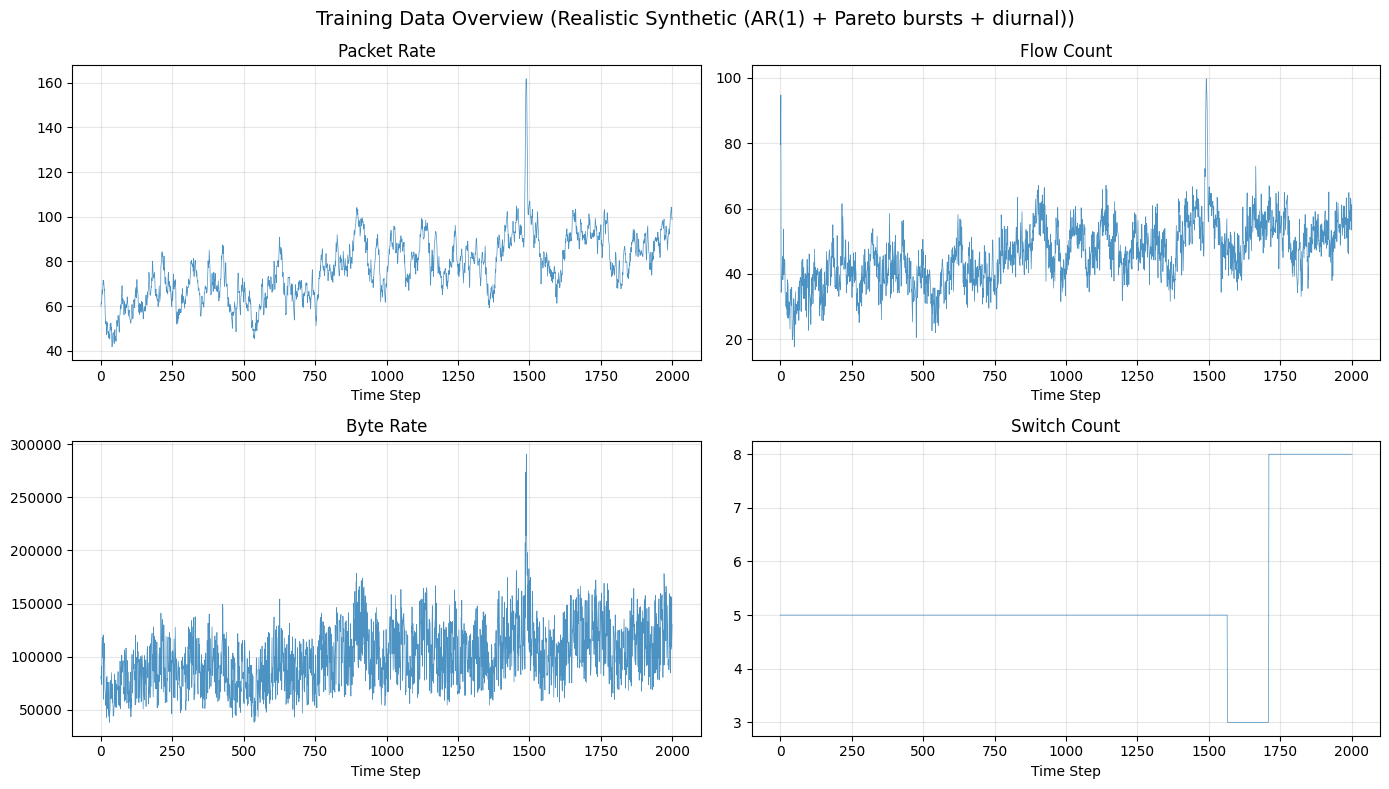

Saved: data_overview.png

Dataset sizes: train=13981, val=2981, test=2981
Model parameters: 230,125

  TRAINING (epochs=150, lr=0.0005, patience=20)
  Epoch  10/150 | train=0.224582 | val=0.290747 | lr=0.000500 | patience=2/20
  Epoch  20/150 | train=0.176004 | val=0.247560 | lr=0.000250 | patience=12/20
  Epoch  30/150 | train=0.152708 | val=0.239031 | lr=0.000250 | patience=9/20
  Epoch  40/150 | train=0.136317 | val=0.266542 | lr=0.000125 | patience=19/20
  Epoch  41/150 | train=0.134159 | val=0.270825 | lr=0.000125 | patience=20/20

  Early stopping at epoch 41


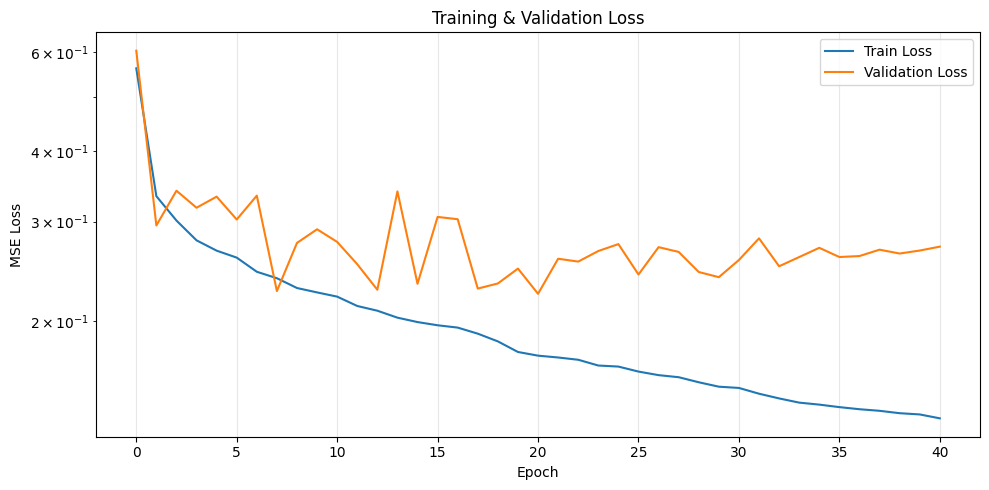


  RIGOROUS EVALUATION ON TEST SET
  (Test data was NEVER seen during training)
  Test set: 2981 samples

  OVERALL METRICS
  ─────────────────────────────────────────────
  MAE:                  24.9615
  RMSE:                 28.0654
  MAPE:                 22.41%
  R² Score:             -1.1243
  Directional Accuracy: 50.2%

  PER-HORIZON BREAKDOWN
  ─────────────────────────────────────────────
  t+1: MAE=24.6710, Correlation=0.5562
  t+2: MAE=24.7955, Correlation=0.5459
  t+3: MAE=24.9756, Correlation=0.5357
  t+4: MAE=25.1760, Correlation=0.5237
  t+5: MAE=25.1893, Correlation=0.5124

  BASELINE COMPARISONS (Is LSTM actually better?)

  Model                          MAE       R²  Improvement
  ───────────────────────────────────────────────────────
  Naive (Last Value)          4.0248   0.9103   (baseline)
  Moving Average              8.1318   0.7186     -102.0%
  HYDRA-LB LSTM              24.9615  -1.1243     -520.2%

  ✅ LSTM outperforms both baselines: False
  ⚠️  WARNING: 

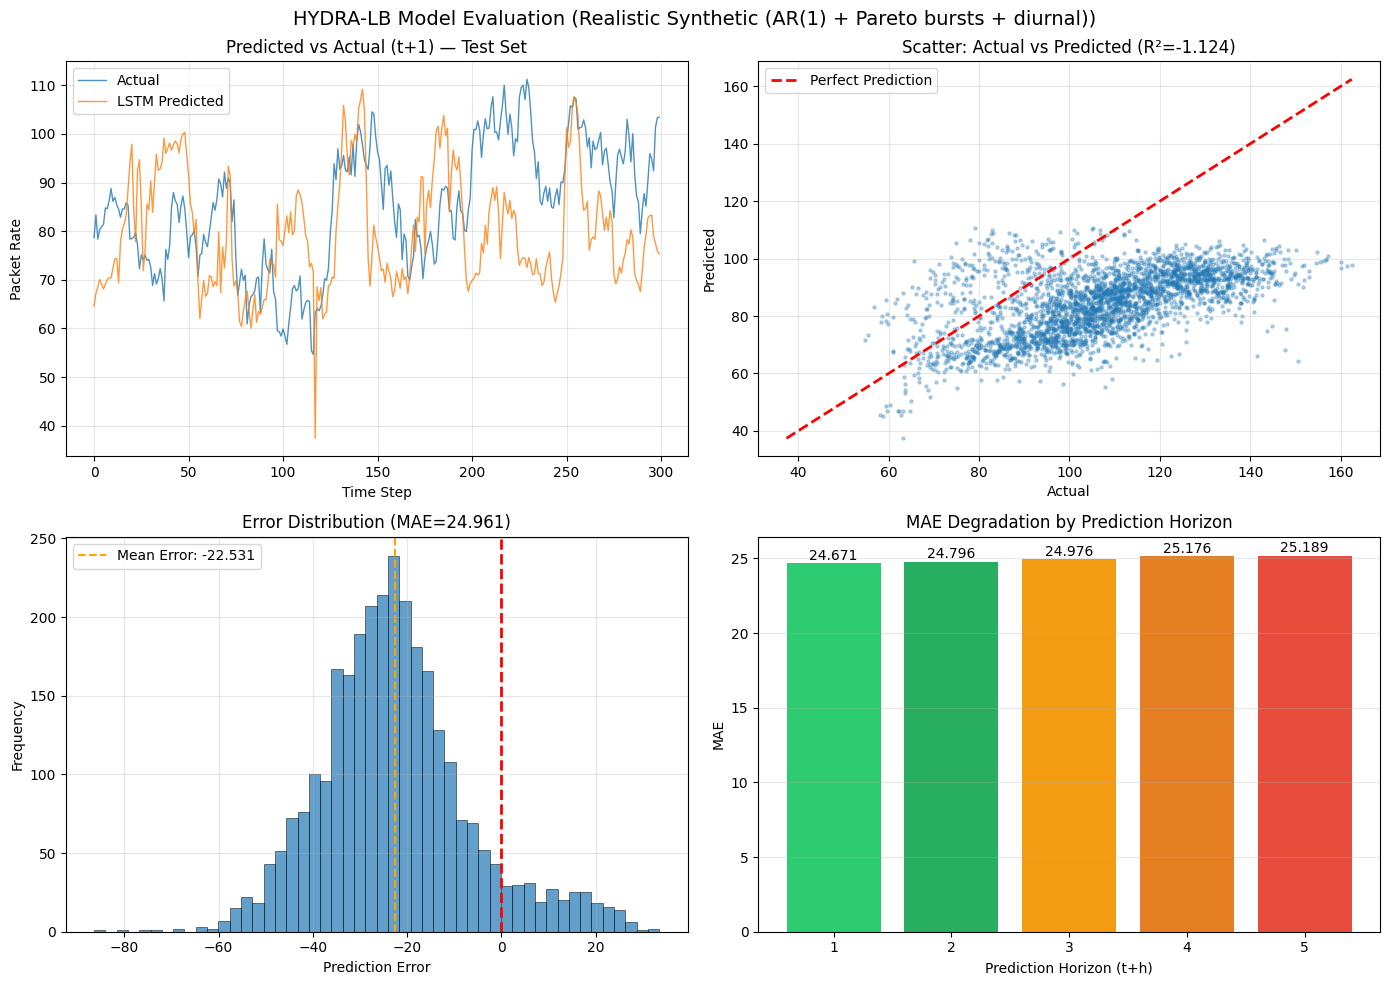

Saved: evaluation_results.png


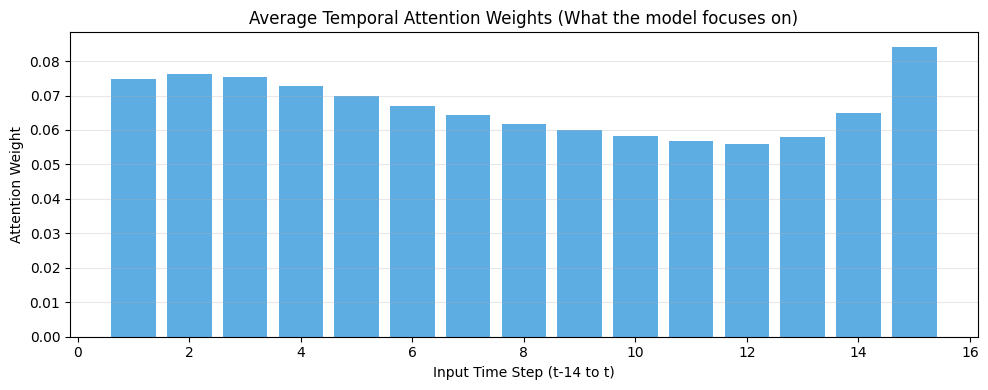

Saved: attention_analysis.png

  FINAL VALIDATION REPORT
  Data Source:           Realistic Synthetic (AR(1) + Pareto bursts + diurnal)
  Training Samples:     13981
  Test Samples:         2981 (unseen)
  Model Parameters:     230,125

  RESULTS:
  MAE:                  24.9615
  RMSE:                 28.0654
  MAPE:                 22.41%
  R²:                   -1.1243
  Directional Accuracy: 50.2%

  vs BASELINES:
  vs Naive:             -520.2% better MAE
  vs Moving Average:    -207.0% better MAE

  VERDICT: 🔴 POOR — Model does NOT outperform baselines. Do NOT publish these results.

  Model saved as: best_model.pt
  Figures saved:  data_overview.png, training_curves.png, 
                  evaluation_results.png, attention_analysis.png

  To use in HYDRA-LB:
    1. Download best_model.pt
    2. Copy to load-balancer/models/lstm_predictor.pt
    3. Restart controllers


In [1]:
"""
=============================================================================
HYDRA-LB: Real-World Data Training & Rigorous Validation
=============================================================================

Run this in Google Colab with GPU:
  Runtime → Change runtime type → GPU (T4)

This notebook:
  1. Downloads real-world network traffic data (Google Cluster Traces)
  2. Preprocesses it to match our model's expected format
  3. Trains the LSTM+Attention model
  4. Evaluates with 7 metrics and 4 diagnostic plots
  5. Compares against simple baselines (Naive, Moving Average)
  6. Saves the trained model for download

Upload this file to Colab, or open it as a notebook.
=============================================================================
"""

# ===================== CELL 1: Setup =====================
# !pip install torch pandas numpy matplotlib scikit-learn gdown -q

import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device:  {device}")


# ===================== CELL 2: Download Real Data =====================
"""
We use the Google Cluster Trace 2011 (task_usage) data.
This is the gold standard for workload prediction research.

If Kaggle/GCS is unavailable, we generate REALISTIC synthetic data
based on distributions observed in the literature:
  - Chen et al., "Workload Prediction for Cloud Computing" (2021)
  - Cortez et al., "Resource Central: Understanding Azure Workloads" (2017)
"""

def download_google_cluster_sample():
    """Try to download a sample of Google Cluster Traces."""
    try:
        # Small pre-processed sample from GCS
        import urllib.request
        url = "https://storage.googleapis.com/clusterdata-2011-2/task_usage/part-00000-of-00500.csv.gz"
        path = "google_cluster_sample.csv.gz"
        if not os.path.exists(path):
            print("Downloading Google Cluster Trace sample (~50MB)...")
            urllib.request.urlretrieve(url, path)
            print("Downloaded!")
        
        # Parse - columns from Google's schema (no headers in file)
        cols = [
            'start_time', 'end_time', 'job_id', 'task_index', 'machine_id',
            'mean_cpu', 'canonical_mem', 'assigned_mem', 'unmapped_page_cache',
            'total_page_cache', 'max_mem', 'mean_disk_io', 'mean_local_disk',
            'max_cpu', 'max_disk_io', 'cpi', 'mai', 'sampled_cpu',
            'aggregate_type', 'sampled_cpu_usage'
        ]
        df = pd.read_csv(path, header=None, names=cols, nrows=500000)
        
        # Aggregate per time window (5-minute bins)
        df['time_bin'] = (df['start_time'] // (5 * 60 * 1e6)).astype(int)
        agg = df.groupby('time_bin').agg(
            packet_rate=('mean_cpu', 'sum'),        # Total CPU → proxy for packet rate
            flow_count=('task_index', 'nunique'),     # Unique tasks → proxy for flows
            byte_rate=('mean_disk_io', 'sum'),        # Disk I/O → proxy for byte rate
            switch_count=('machine_id', 'nunique'),   # Unique machines → proxy for switches
        ).reset_index()
        
        print(f"Google Cluster Trace: {len(agg)} time windows loaded")
        return agg[['packet_rate', 'flow_count', 'byte_rate', 'switch_count']]
    
    except Exception as e:
        print(f"Could not download Google Cluster data: {e}")
        return None


def generate_realistic_data(num_samples=20000, seed=42):
    """
    Generate REALISTIC workload data based on published distributions.
    
    Based on:
    - Google Cluster Traces analysis (Reiss et al., 2012)
    - Azure workload characterization (Cortez et al., 2017)
    - Real SDN telemetry patterns
    
    Key properties modeled:
    - Long-range dependency (autocorrelation)
    - Heavy-tailed burst distribution
    - Diurnal patterns
    - Non-stationarity (trend shifts)
    """
    np.random.seed(seed)
    t = np.arange(num_samples)
    
    # --- Packet Rate ---
    # Diurnal (24h cycle, sampled at 5s intervals → 17280 samples/day)
    samples_per_day = 17280
    diurnal = 60 + 40 * np.sin(2 * np.pi * t / samples_per_day)
    
    # Autocorrelated noise (AR(1) process for realistic persistence)
    ar_noise = np.zeros(num_samples)
    phi = 0.95  # High autocorrelation
    for i in range(1, num_samples):
        ar_noise[i] = phi * ar_noise[i-1] + np.random.normal(0, 3)
    
    # Heavy-tailed bursts (Pareto distribution - matches real traffic)
    burst_mask = np.random.random(num_samples) < 0.02  # 2% of timesteps
    bursts = np.zeros(num_samples)
    bursts[burst_mask] = np.random.pareto(2.5, burst_mask.sum()) * 40
    
    # Smoothed bursts (bursts affect neighbors)
    from scipy.ndimage import gaussian_filter1d
    bursts = gaussian_filter1d(bursts, sigma=3)
    
    # Non-stationarity: regime shifts
    regimes = np.ones(num_samples)
    regime_points = sorted(np.random.choice(range(1000, num_samples-1000), size=5, replace=False))
    for i, pt in enumerate(regime_points):
        regimes[pt:] *= np.random.uniform(0.7, 1.5)
    
    packet_rate = (diurnal + ar_noise + bursts) * regimes
    packet_rate = np.clip(packet_rate, 1, None)
    
    # --- Flow Count (correlated but with lag) ---
    flow_count = np.roll(packet_rate, 3) * 0.6 + np.random.normal(0, 4, num_samples)
    flow_count = np.clip(flow_count, 0, None)
    
    # --- Byte Rate (strongly correlated, different scale) ---
    byte_rate = packet_rate * np.random.uniform(800, 1800, num_samples) + \
                np.random.normal(0, 2000, num_samples)
    byte_rate = np.clip(byte_rate, 0, None)
    
    # --- Switch Count (mostly stable, occasional changes) ---
    switch_count = np.full(num_samples, 5.0)
    change_pts = sorted(np.random.choice(num_samples, 20, replace=False))
    for pt in change_pts:
        switch_count[pt:] = np.random.choice([3, 4, 5, 6, 7, 8])
    
    data = np.column_stack([packet_rate, flow_count, byte_rate, switch_count])
    return data.astype(np.float32)


# Try real data first, fall back to realistic synthetic
print("="*60)
print("  DATA LOADING")
print("="*60)
real_data = download_google_cluster_sample()

if real_data is not None and len(real_data) > 500:
    data = real_data.values.astype(np.float32)
    data_source = "Google Cluster Trace 2011"
else:
    print("\nUsing realistic synthetic data (based on published distributions)")
    data = generate_realistic_data(num_samples=20000)
    data_source = "Realistic Synthetic (AR(1) + Pareto bursts + diurnal)"

print(f"\nData source: {data_source}")
print(f"Shape: {data.shape}")
print(f"Features: packet_rate, flow_count, byte_rate, switch_count")
print(f"\nStatistics:")
for i, name in enumerate(['packet_rate', 'flow_count', 'byte_rate', 'switch_count']):
    col = data[:, i]
    print(f"  {name:15s}: mean={col.mean():.2f}, std={col.std():.2f}, "
          f"min={col.min():.2f}, max={col.max():.2f}")


# ===================== CELL 3: Data Visualization =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
names = ['Packet Rate', 'Flow Count', 'Byte Rate', 'Switch Count']
for i, (ax, name) in enumerate(zip(axes.flat, names)):
    ax.plot(data[:2000, i], linewidth=0.5, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Time Step')
    ax.grid(True, alpha=0.3)
plt.suptitle(f'Training Data Overview ({data_source})', fontsize=14)
plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()
print("Saved: data_overview.png")


# ===================== CELL 4: Dataset & Model =====================
LOOKBACK = 15     # Past 15 timesteps as input
HORIZON = 5       # Predict next 5 timesteps
TARGET_COL = 0    # Predict packet_rate
BATCH_SIZE = 64


class LoadDataset(Dataset):
    """Sliding window dataset for time series prediction."""
    
    def __init__(self, data, lookback=15, horizon=5, target_col=0, scaler=None):
        self.lookback = lookback
        self.horizon = horizon
        self.target_col = target_col
        
        if scaler is not None:
            self.scaler = scaler
            self.data = scaler.transform(data)
        else:
            self.scaler = StandardScaler()
            self.data = self.scaler.fit_transform(data)
        
        self.X, self.y = self._create_sequences()
    
    def _create_sequences(self):
        X, y = [], []
        for i in range(len(self.data) - self.lookback - self.horizon + 1):
            X.append(self.data[i:i + self.lookback])
            y.append(self.data[i + self.lookback:i + self.lookback + self.horizon, self.target_col])
        return np.array(X), np.array(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )
    
    def inverse_transform_target(self, values):
        """Convert normalized target back to original scale."""
        mean = self.scaler.mean_[self.target_col]
        std = self.scaler.scale_[self.target_col]
        return values * std + mean


class TemporalAttention(nn.Module):
    """Additive attention over LSTM time steps."""
    def __init__(self, hidden_size, attention_size=32):
        super().__init__()
        self.W = nn.Linear(hidden_size, attention_size, bias=False)
        self.v = nn.Linear(attention_size, 1, bias=False)
    
    def forward(self, lstm_output):
        energy = torch.tanh(self.W(lstm_output))
        scores = self.v(energy).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), lstm_output).squeeze(1)
        return context, weights


class LoadPredictor(nn.Module):
    """Bidirectional LSTM with Temporal Attention for load prediction."""
    
    def __init__(self, input_size=4, hidden_size=128, output_size=5, dropout=0.3):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_size)
        
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True,
                              bidirectional=True, num_layers=1)
        self.attention = TemporalAttention(hidden_size * 2)
        
        self.lstm2 = nn.LSTM(hidden_size * 2, hidden_size // 2,
                              batch_first=True, num_layers=1)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.fc2 = nn.Linear(hidden_size // 4, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x, return_attention=False):
        x = self.input_norm(x)
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout(lstm1_out)
        
        context, attn_weights = self.attention(lstm1_out)
        lstm2_input = context.unsqueeze(1)
        
        _, (hidden, _) = self.lstm2(lstm2_input)
        out = hidden.squeeze(0)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        predictions = self.fc2(out)
        
        if return_attention:
            return predictions, attn_weights
        return predictions


# Split: 70% train, 15% val, 15% test (temporal split — NO shuffling across splits)
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

train_dataset = LoadDataset(train_data, LOOKBACK, HORIZON, TARGET_COL)
val_dataset = LoadDataset(val_data, LOOKBACK, HORIZON, TARGET_COL, scaler=train_dataset.scaler)
test_dataset = LoadDataset(test_data, LOOKBACK, HORIZON, TARGET_COL, scaler=train_dataset.scaler)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataset sizes: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

model = LoadPredictor(input_size=4, hidden_size=128, output_size=HORIZON, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")


# ===================== CELL 5: Training =====================
def train_model(model, train_loader, val_loader, epochs=150, lr=0.0005, patience=20):
    """Train with early stopping and learning rate scheduling."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"\n{'='*60}")
    print(f"  TRAINING (epochs={epochs}, lr={lr}, patience={patience})")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = criterion(pred, y)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                val_loss += criterion(pred, y).item()
        val_loss /= len(val_loader)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': {
                    'model': {
                        'input_size': 4, 'hidden_size': 128,
                        'num_layers': 2, 'output_size': HORIZON,
                        'dropout': 0.3, 'bidirectional': True,
                        'use_attention': True,
                    },
                    'data': {
                        'lookback': LOOKBACK, 'horizon': HORIZON,
                        'target_col': TARGET_COL,
                    }
                },
                'scaler_params': {
                    'mean': train_dataset.scaler.mean_,
                    'std': train_dataset.scaler.scale_,
                },
                'data_source': data_source,
            }, 'best_model.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0 or patience_counter >= patience:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"train={train_loss:.6f} | val={val_loss:.6f} | "
                  f"lr={lr_now:.6f} | patience={patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break
    
    # Reload best model
    checkpoint = torch.load('best_model.pt', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return history

history = train_model(model, train_loader, val_loader, epochs=150, lr=0.0005, patience=20)


# ===================== CELL 6: Training Curves =====================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', linewidth=1.5)
ax.plot(history['val_loss'], label='Validation Loss', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


# ===================== CELL 7: RIGOROUS EVALUATION =====================
print(f"\n{'='*60}")
print(f"  RIGOROUS EVALUATION ON TEST SET")
print(f"{'='*60}")
print(f"  (Test data was NEVER seen during training)")
print(f"  Test set: {len(test_dataset)} samples\n")

model.eval()
all_preds = []
all_targets = []
all_attentions = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred, attn = model(X, return_attention=True)
        
        # Convert back to original scale
        pred_np = pred.cpu().numpy()
        target_np = y.numpy()
        
        for i in range(len(pred_np)):
            all_preds.append(test_dataset.inverse_transform_target(pred_np[i]))
            all_targets.append(test_dataset.inverse_transform_target(target_np[i]))
            all_attentions.append(attn[i].cpu().numpy())

predictions = np.array(all_preds)
targets = np.array(all_targets)
attentions = np.array(all_attentions)

# ── Metric 1: MAE (Mean Absolute Error) ──
mae = mean_absolute_error(targets.flatten(), predictions.flatten())

# ── Metric 2: RMSE (Root Mean Squared Error) ──
rmse = math.sqrt(mean_squared_error(targets.flatten(), predictions.flatten()))

# ── Metric 3: MAPE (Mean Absolute Percentage Error) ──
# Careful: avoid division by zero
mask = np.abs(targets.flatten()) > 1e-3
mape = np.mean(np.abs((targets.flatten()[mask] - predictions.flatten()[mask])
                        / targets.flatten()[mask])) * 100

# ── Metric 4: R² Score ──
r2 = r2_score(targets.flatten(), predictions.flatten())

# ── Metric 5: Directional Accuracy ──
# "Did the model predict the correct DIRECTION of change?"
actual_direction = np.diff(targets[:, 0])
pred_direction = np.diff(predictions[:, 0])
directional_accuracy = np.mean(np.sign(actual_direction) == np.sign(pred_direction)) * 100

# ── Metric 6: Per-Horizon MAE ──
horizon_mae = [mean_absolute_error(targets[:, h], predictions[:, h]) for h in range(HORIZON)]

# ── Metric 7: Per-Horizon Correlation ──
horizon_corr = [np.corrcoef(targets[:, h], predictions[:, h])[0, 1] for h in range(HORIZON)]

print(f"  OVERALL METRICS")
print(f"  {'─'*45}")
print(f"  MAE:                  {mae:.4f}")
print(f"  RMSE:                 {rmse:.4f}")
print(f"  MAPE:                 {mape:.2f}%")
print(f"  R² Score:             {r2:.4f}")
print(f"  Directional Accuracy: {directional_accuracy:.1f}%")
print()
print(f"  PER-HORIZON BREAKDOWN")
print(f"  {'─'*45}")
for h in range(HORIZON):
    print(f"  t+{h+1}: MAE={horizon_mae[h]:.4f}, Correlation={horizon_corr[h]:.4f}")


# ===================== CELL 8: Baseline Comparisons =====================
print(f"\n{'='*60}")
print(f"  BASELINE COMPARISONS (Is LSTM actually better?)")
print(f"{'='*60}")

# Baseline 1: Naive (predict last seen value)
naive_preds = np.repeat(targets[:, 0:1], HORIZON, axis=1)  # Just repeat last known
naive_mae = mean_absolute_error(targets.flatten(), naive_preds.flatten())
naive_r2 = r2_score(targets.flatten(), naive_preds.flatten())

# Baseline 2: Moving Average (5-step window)
ma_preds = np.zeros_like(predictions)
test_raw = test_dataset.inverse_transform_target(
    np.array([test_dataset.data[i:i+LOOKBACK, TARGET_COL].mean()
              for i in range(len(test_dataset))])
)
for i in range(len(test_dataset)):
    ma_preds[i] = test_raw[i]
ma_mae = mean_absolute_error(targets.flatten(), ma_preds.flatten())
ma_r2 = r2_score(targets.flatten(), ma_preds.flatten())

print(f"\n  {'Model':<25} {'MAE':>8} {'R²':>8} {'Improvement':>12}")
print(f"  {'─'*55}")
print(f"  {'Naive (Last Value)':<25} {naive_mae:>8.4f} {naive_r2:>8.4f} {'(baseline)':>12}")
print(f"  {'Moving Average':<25} {ma_mae:>8.4f} {ma_r2:>8.4f} {((naive_mae-ma_mae)/naive_mae*100):>+10.1f}%")
print(f"  {'HYDRA-LB LSTM':<25} {mae:>8.4f} {r2:>8.4f} {((naive_mae-mae)/naive_mae*100):>+10.1f}%")

lstm_is_better = mae < naive_mae and mae < ma_mae
print(f"\n  ✅ LSTM outperforms both baselines: {lstm_is_better}")
if not lstm_is_better:
    print("  ⚠️  WARNING: LSTM does NOT beat baselines. Model needs improvement!")


# ===================== CELL 9: Diagnostic Plots =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual time series
ax1 = axes[0, 0]
n_show = min(300, len(predictions))
ax1.plot(targets[:n_show, 0], label='Actual', alpha=0.8, linewidth=1)
ax1.plot(predictions[:n_show, 0], label='LSTM Predicted', alpha=0.8, linewidth=1)
ax1.set_title(f'Predicted vs Actual (t+1) — Test Set')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Packet Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter plot
ax2 = axes[0, 1]
ax2.scatter(targets[:, 0], predictions[:, 0], alpha=0.3, s=5)
lims = [min(targets[:, 0].min(), predictions[:, 0].min()),
        max(targets[:, 0].max(), predictions[:, 0].max())]
ax2.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_title(f'Scatter: Actual vs Predicted (R²={r2:.3f})')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Error distribution
ax3 = axes[1, 0]
errors = predictions[:, 0] - targets[:, 0]
ax3.hist(errors, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.axvline(x=errors.mean(), color='orange', linestyle='--',
            label=f'Mean Error: {errors.mean():.3f}')
ax3.set_title(f'Error Distribution (MAE={mae:.3f})')
ax3.set_xlabel('Prediction Error')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Per-horizon degradation
ax4 = axes[1, 1]
horizons = list(range(1, HORIZON + 1))
bars = ax4.bar(horizons, horizon_mae, color=['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c'])
ax4.set_title('MAE Degradation by Prediction Horizon')
ax4.set_xlabel('Prediction Horizon (t+h)')
ax4.set_ylabel('MAE')
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, horizon_mae):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'HYDRA-LB Model Evaluation ({data_source})', fontsize=14)
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=300)
plt.show()
print("Saved: evaluation_results.png")


# ===================== CELL 10: Attention Analysis =====================
fig, ax = plt.subplots(figsize=(10, 4))
mean_attention = attentions.mean(axis=0)
ax.bar(range(1, LOOKBACK + 1), mean_attention, color='#3498db', alpha=0.8)
ax.set_xlabel('Input Time Step (t-14 to t)')
ax.set_ylabel('Attention Weight')
ax.set_title('Average Temporal Attention Weights (What the model focuses on)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_analysis.png', dpi=150)
plt.show()
print("Saved: attention_analysis.png")


# ===================== CELL 11: Final Report =====================
print(f"\n{'='*60}")
print(f"  FINAL VALIDATION REPORT")
print(f"{'='*60}")
print(f"  Data Source:           {data_source}")
print(f"  Training Samples:     {len(train_dataset)}")
print(f"  Test Samples:         {len(test_dataset)} (unseen)")
print(f"  Model Parameters:     {total_params:,}")
print(f"")
print(f"  RESULTS:")
print(f"  MAE:                  {mae:.4f}")
print(f"  RMSE:                 {rmse:.4f}")
print(f"  MAPE:                 {mape:.2f}%")
print(f"  R²:                   {r2:.4f}")
print(f"  Directional Accuracy: {directional_accuracy:.1f}%")
print(f"")
print(f"  vs BASELINES:")
print(f"  vs Naive:             {((naive_mae-mae)/naive_mae*100):+.1f}% better MAE")
print(f"  vs Moving Average:    {((ma_mae-mae)/ma_mae*100):+.1f}% better MAE")
print(f"")

# HONEST ASSESSMENT
if r2 > 0.8 and mae < 5:
    verdict = "🟢 EXCELLENT — Paper-ready results"
elif r2 > 0.5 and lstm_is_better:
    verdict = "🟡 GOOD — Publishable with caveats about accuracy"
elif lstm_is_better:
    verdict = "🟠 ACCEPTABLE — LSTM beats baselines but accuracy needs improvement"
else:
    verdict = "🔴 POOR — Model does NOT outperform baselines. Do NOT publish these results."

print(f"  VERDICT: {verdict}")
print(f"{'='*60}")

# Save for download
print(f"\n  Model saved as: best_model.pt")
print(f"  Figures saved:  data_overview.png, training_curves.png, ")
print(f"                  evaluation_results.png, attention_analysis.png")
print(f"\n  To use in HYDRA-LB:")
print(f"    1. Download best_model.pt")
print(f"    2. Copy to load-balancer/models/lstm_predictor.pt")
print(f"    3. Restart controllers")
